# Semantic Segmentation Visualization and Class Analysis

This notebook overlays semantic segmentation labels on top of an input image, and analyzes the unique classes present in the label image.

- **Overlay segmented sections on the original image**
- **Count and display all unique classes in the label**

> **Assumptions:**
> - The original image is a `.jpg` file (sample: ![image2](image2))
> - The segmentation label is a `.png` file with the same shape as the image (sample: ![image1](image1))
> - Classes are encoded as unique pixel values in the `label.png` (e.g. 0=background, 1=sky, 2=crop, 3=soil, ...)
> - You may need to edit the path to your own image/label files


In [6]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- File Paths (edit as needed) ---
image_path = 'dataset/images/DJI_0048_06.JPG'   # Replace with your image filename
label_path = 'dataset/labels/DJI_0048_06.png'   # Replace with your label filename


In [7]:
# --- Load Images ---
image = np.array(Image.open(image_path).convert('RGB'))
label = np.array(Image.open(label_path))

print(f"Image shape: {image.shape}")
print(f"Label shape: {label.shape}")

Image shape: (1530, 2720, 3)
Label shape: (1530, 2720)


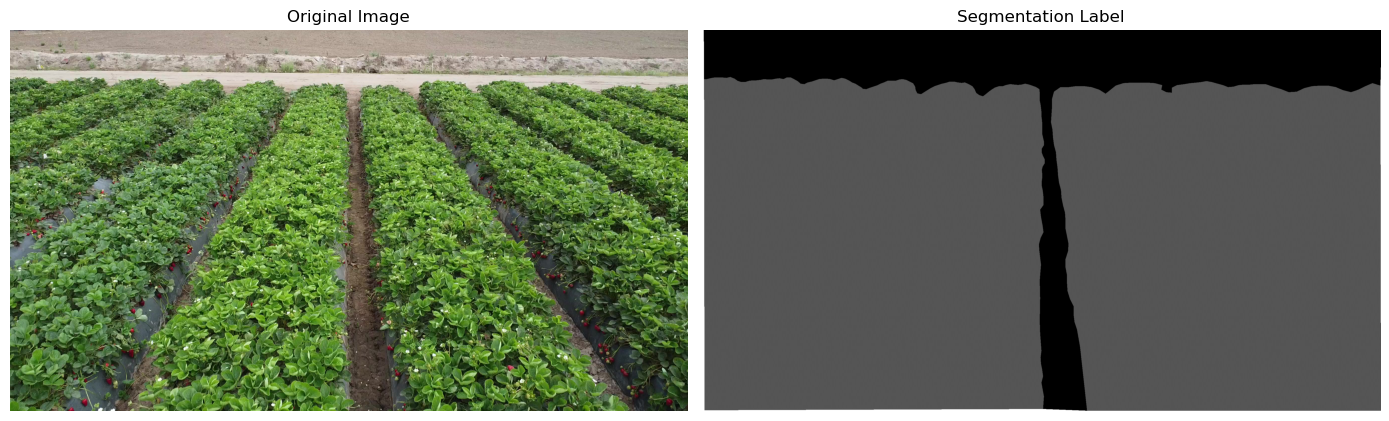

In [8]:
# --- View the Images ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].imshow(image)
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(label, cmap='gray')
axs[1].set_title('Segmentation Label')
axs[1].axis('off')
plt.tight_layout()
plt.show()

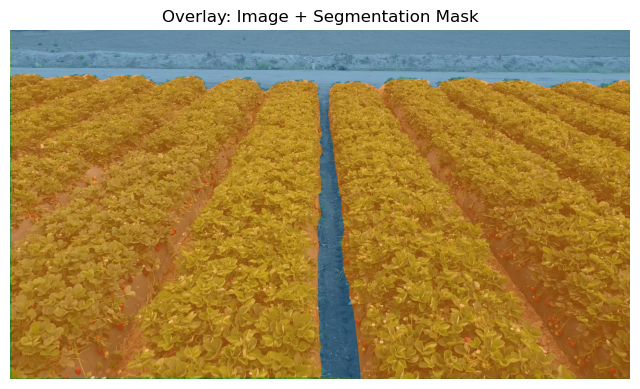

In [9]:
# --- Overlay Segmentation Mask ---
def label_to_color(label_img, colormap=None):
    """
    Map the label image to a color image for visualization.
    If colormap is None, use a default color palette.
    """
    unique_classes = np.unique(label_img)
    n_classes = unique_classes.size
    if colormap is None:
        # Use matplotlib's tab10 colormap for up to 10 classes
        base_cmap = plt.get_cmap('tab10')
        colors = (np.array(base_cmap.colors) * 255).astype(np.uint8)
        # Repeat if more than 10 classes
        colors = np.vstack([colors for _ in range((n_classes // 10) + 1)])
    else:
        colors = colormap
    # Map each label to a color
    label_color = np.zeros((*label_img.shape, 3), dtype=np.uint8)
    for idx, cls in enumerate(unique_classes):
        label_color[label_img == cls] = colors[idx % colors.shape[0]]
    return label_color

label_color = label_to_color(label)
# Blend the color mask with the image
alpha = 0.5
overlay = (image * (1 - alpha) + label_color * alpha).astype(np.uint8)

plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.title('Overlay: Image + Segmentation Mask')
plt.axis('off')
plt.show()

In [10]:
# --- Find All Unique Classes in the Label ---
unique_classes = np.unique(label)
print(f"Unique class indices in label: {unique_classes}")
print(f"Number of classes: {len(unique_classes)})")

# Optional: Map indices to class names (edit as per your dataset)
class_names = {
    0: 'background/soil',
    1: 'crop',
    2: 'sky',
    # Add more as needed
}
print("Class mapping (edit as needed):")
for cls in unique_classes:
    print(f"  {cls}: {class_names.get(cls, 'Unknown')}")

Unique class indices in label: [0 2 6]
Number of classes: 3)
Class mapping (edit as needed):
  0: background/soil
  2: sky
  6: Unknown


## References
- See the repository's training scripts or label definitions for the exact mapping of class indices to names.
- Modify the `class_names` dictionary above as needed to fit your dataset.
